**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 6**
Ingeniería de características (FE)

---

*   NOMBRE: Gabriela Parra Aguilar,
*   MATRÍCULA: A01753492,

En esta actividad trabajarás con el archivo `computer_prices.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de computadoras portátiles y de escritorio, disponible en Kaggle.

Los datos fueron recopilados para analizar el rendimiento y el precio de los dispositivos, e incluyen información sobre hardware, almacenamiento, conectividad y otras especificaciones técnicas. Los indicadores incluidos son:

* `device_type`: Tipo de dispositivo (ej. laptop, desktop)
* `brand`: Marca del dispositivo
* `model`: Modelo del dispositivo
* `release_year`: Año de lanzamiento del dispositivo
* `os`: Sistema operativo instalado
* `form_factor`: Factor de forma o diseño del dispositivo (ej. laptop, ultrabook, desktop tower)
* `cpu_brand`: Marca del procesador
* `cpu_tier`: Nivel o gama del procesador, ordinal del 1 al 6 según desempeño
* `cpu_cores`: Número de núcleos del procesador
* `cpu_threads`: Número de hilos de ejecución del procesador
* `gpu_brand`: Marca de la tarjeta gráfica
* `gpu_model`: Modelo específico de la tarjeta gráfica
* `gpu_tier`: Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño
* `vram_gb`: Memoria de video de la GPU en gigabytes
* `ram_gb`: Memoria RAM del dispositivo en gigabytes
* `storage_type`: Tipo de almacenamiento (ej. HDD, SSD)
* `storage_gb`: Capacidad de almacenamiento en gigabytes
* `storage_drive_count`: Número de unidades de almacenamiento instaladas
* `display_type`: Tipo de pantalla (ej. IPS, TN, OLED)
* `charger_watts`: Potencia del cargador (en watts) para laptops
* `psu_watts`: Potencia de la fuente de poder (en watts) para desktops
* `wifi`: Estándar de conectividad Wi-Fi (ej. Wi-Fi 5, 6, 6E, 7)
* `bluetooth`: Versión de Bluetooth
* `weight_kg`: Peso del dispositivo en kilogramos
* `warranty_months`: Meses de garantía del dispositivo
* `price`: Precio del dispositivo. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Instalar las bibliotecas necesarias
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.6 MB/s eta 0:00:00


In [2]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder
from scipy import stats

1. Descarga el archivo: `computer_prices.csv` y guarda, en un dataframe (`compu_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Elimina las variables:
  * `model`: Debido a su altísima cardinalidad, lo que dificulta su uso en análisis y modelado.
  * `cpu_model`: Además de su elevada cardinalidad, su información ya está representada de manera implícita en otras variables como: `cpu_tier`, `cpu_cores` y `cpu_threads`

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Descarga el archivo: computer_prices.csv y guarda, en un dataframe (compu_df), todos sus registros.
ruta_archivo = "/content/drive/MyDrive/Colab Notebooks/Maestria en IA/Ciencia de datos enero 2026/computer_prices.csv"
compu_df = pd.read_csv(ruta_archivo)

In [5]:
#Utiliza el método info()
compu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  gpu_brand            100000 non-null  object 
 12  gpu_model            100000 non-null  object 
 13  gpu_tier             100000 non-null  int64  
 14  vram_gb              100000 non-null  int64  
 15  ram_gb            

Son 15 columnas numericas y 12 son de texto

In [6]:
#Determina la cantidad de valores únicos por columna.
compu_df.nunique()

,0
device_type,2
brand,10
model,99036
release_year,8
os,4
form_factor,10
cpu_brand,3
cpu_model,26971
cpu_tier,6
cpu_cores,12


In [7]:
#Elimina las variables model y cpu_model

compu_df.drop(columns=['model', 'cpu_model'], inplace=True)

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados y/o faltantes.
* Obtén las estadísticas descriptivas, separado las numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Genera histogramas para las numéricas y diagramas de barras para las categóricas. Con alta cardinalidad, sólo incluye los 10 valores más frecuentes.

In [8]:
# Duplicados y faltantes
print(f"Duplicados: {compu_df.duplicated().sum()}")
print(f"Faltantes:\n{compu_df.isnull().sum()}")

Duplicados: 0
Faltantes:
device_type            0
brand                  0
release_year           0
os                     0
form_factor            0
cpu_brand              0
cpu_tier               0
cpu_cores              0
cpu_threads            0
gpu_brand              0
gpu_model              0
gpu_tier               0
vram_gb                0
ram_gb                 0
storage_type           0
storage_gb             0
storage_drive_count    0
display_type           0
charger_watts          0
psu_watts              0
wifi                   0
bluetooth              0
weight_kg              0
warranty_months        0
price                  0
dtype: int64


In [9]:
# Guardar el resumen básico (media, min, max, etc.)
resumen_num = compu_df.select_dtypes(include='number').describe()

# Agregar las filas de sesgo (skew) y curtosis (kurt)
resumen_num.loc['skew'] = compu_df.select_dtypes(include='number').skew()
resumen_num.loc['kurt'] = compu_df.select_dtypes(include='number').kurt()

resumen_num

,release_year,cpu_tier,cpu_cores,cpu_threads,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,charger_watts,psu_watts,bluetooth,weight_kg,warranty_months,price
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022.320850,3.153490,10.515740,19.372700,2.991350,6.152180,39.706400,903.936000,1.524980,61.383450,272.520500,5.084764,4.289699,22.200360,1928.764220
std,2.025761,1.373175,5.044092,9.718426,1.459643,3.964926,31.902684,774.243654,0.797284,62.795034,354.686355,0.245977,3.814628,10.231900,580.492689
min,2018.000000,1.000000,4.000000,4.000000,1.000000,0.000000,8.000000,256.000000,1.000000,0.000000,0.000000,4.200000,0.920000,12.000000,372.990000
25%,2021.000000,2.000000,6.000000,12.000000,2.000000,4.000000,16.000000,512.000000,1.000000,0.000000,0.000000,5.000000,1.500000,12.000000,1503.990000
50%,2023.000000,3.000000,8.000000,16.000000,3.000000,6.000000,32.000000,512.000000,1.000000,65.000000,0.000000,5.100000,2.000000,24.000000,1863.990000
75%,2024.000000,4.000000,14.000000,24.000000,4.000000,8.000000,64.000000,1024.000000,2.000000,90.000000,650.000000,5.200000,7.000000,24.000000,2287.990000
max,2025.000000,6.000000,28.000000,56.000000,6.000000,16.000000,144.000000,4096.000000,4.000000,240.000000,1200.000000,5.300000,16.000000,48.000000,10984.990000
skew,-0.479062,0.174307,1.087762,1.125744,0.285752,0.281362,1.049278,2.304037,1.540038,0.855735,0.765531,-2.624593,1.180902,0.775813,0.986644
kurt,-0.715846,-0.751699,1.007646,1.300012,-0.851269,-0.354864,0.195870,6.272154,1.746179,0.238015,-0.940812,7.064988,0.362507,-0.085918,4.891446


In [10]:
# Resumen estadístico de textos (cantidad, únicos, el que más se repite y su frecuencia)
compu_df.select_dtypes(include='object').describe()
compu_df

,device_type,brand,release_year,os,form_factor,cpu_brand,cpu_tier,cpu_cores,cpu_threads,gpu_brand,...,storage_gb,storage_drive_count,display_type,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,2022,Windows,ATX,Intel,3,12,24,NVIDIA,...,1024,1,LED,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,2022,Windows,Mainstream,Intel,4,12,24,NVIDIA,...,512,1,OLED,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,2024,macOS,SFF,AMD,2,8,16,NVIDIA,...,512,2,LED,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,2024,Windows,ATX,AMD,2,6,12,AMD,...,512,2,IPS,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,2024,Linux,Gaming,AMD,5,16,32,NVIDIA,...,256,1,Mini-LED,90,0,Wi-Fi 6,5.2,1.50,12,2681.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Laptop,ASUS,2023,Windows,Mainstream,Intel,4,12,24,AMD,...,2048,1,LED,180,0,Wi-Fi 6,5.1,1.87,24,1712.99
99996,Laptop,Lenovo,2018,Windows,Ultrabook,AMD,2,8,16,AMD,...,1024,1,LED,65,0,Wi-Fi 6,5.1,1.37,12,1258.99
99997,Laptop,ASUS,2020,Windows,Mainstream,Intel,2,6,10,NVIDIA,...,1024,1,OLED,180,0,Wi-Fi 6,4.2,1.17,12,1686.99
99998,Laptop,ASUS,2020,Windows,Mainstream,AMD,4,12,24,NVIDIA,...,256,1,OLED,90,0,Wi-Fi 6,5.3,1.70,24,2164.99


In [11]:
# Tablas de frecuencia]
for col in compu_df.select_dtypes(include='object').columns:
    # Mostramos el nombre de la columna y su Top 10
    display(compu_df[col].value_counts().head(10).to_frame())

,count
device_type,
Laptop,59844
Desktop,40156


,count
brand,
Lenovo,15992
HP,14114
Dell,14005
Apple,11915
ASUS,10159
Acer,9925
Samsung,8066
MSI,7891
Gigabyte,4900


,count
os,
Windows,71817
macOS,18207
Linux,6109
ChromeOS,3867


,count
form_factor,
Mainstream,17819
Gaming,16876
ATX,15597
Ultrabook,13236
Micro-ATX,8672
Full-Tower,7110
2-in-1,7049
SFF,5585
Workstation,4864


,count
cpu_brand,
Intel,52774
AMD,35311
Apple,11915


,count
gpu_brand,
NVIDIA,54712
Apple,18922
AMD,15767
Intel,10599


,count
gpu_model,
Apple Integrated,18922
RTX 40 70,5743
RTX 30 70,5692
RTX 40 60,5437
RTX 30 60,5314
RTX 30 50,5046
RTX 40 50,4970
RTX 40 80,4676
RTX 30 80,4618


,count
storage_type,
NVMe,45059
SSD,24937
HDD,15023
Hybrid,14981


,count
display_type,
LED,32000
OLED,21910
IPS,17742
Mini-LED,12188
QLED,10069
VA,6091


,count
wifi,
Wi-Fi 6,46149
Wi-Fi 6E,25923
Wi-Fi 5,19926
Wi-Fi 7,8002


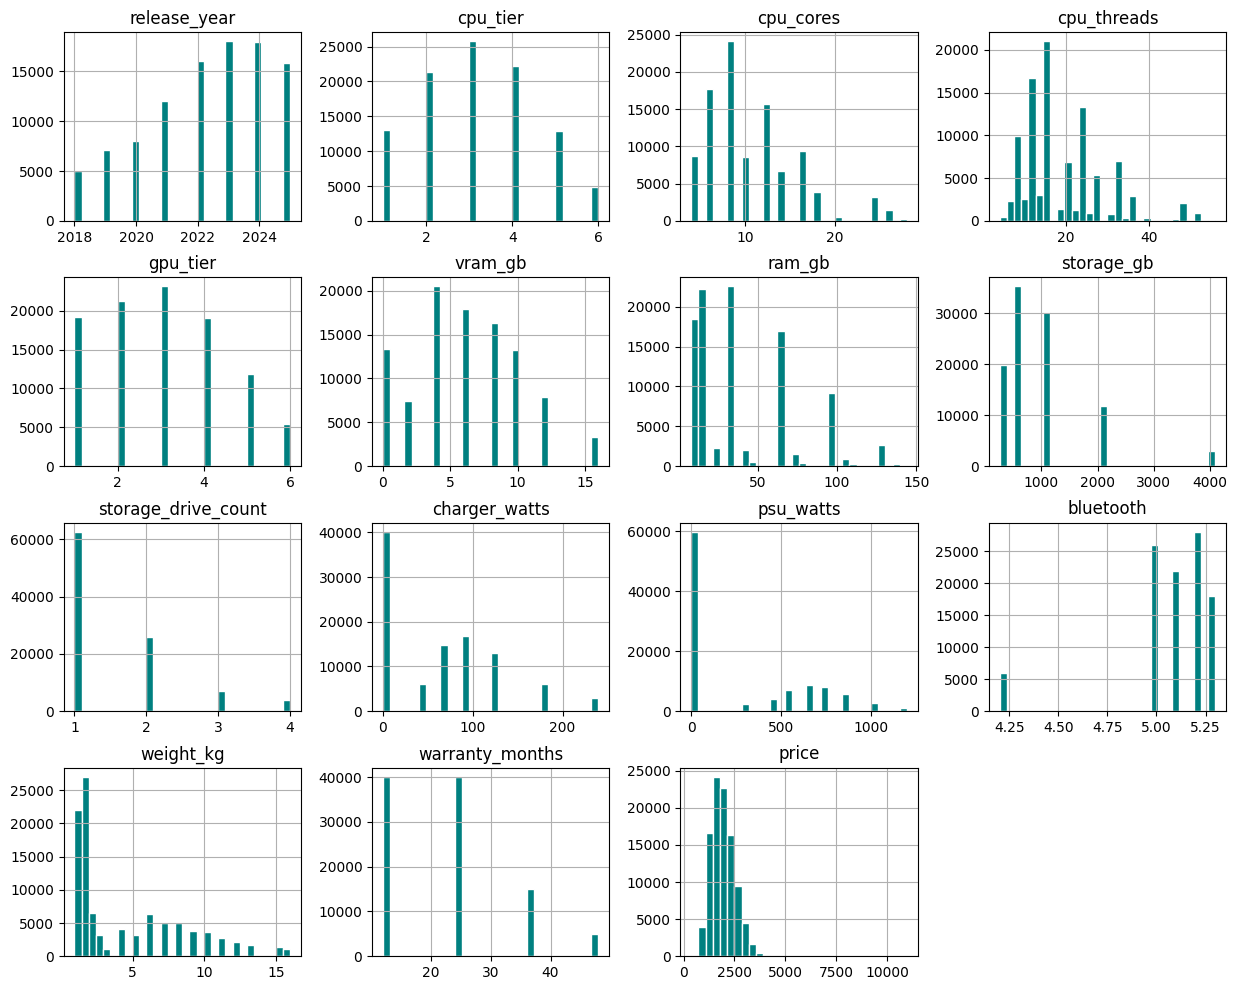

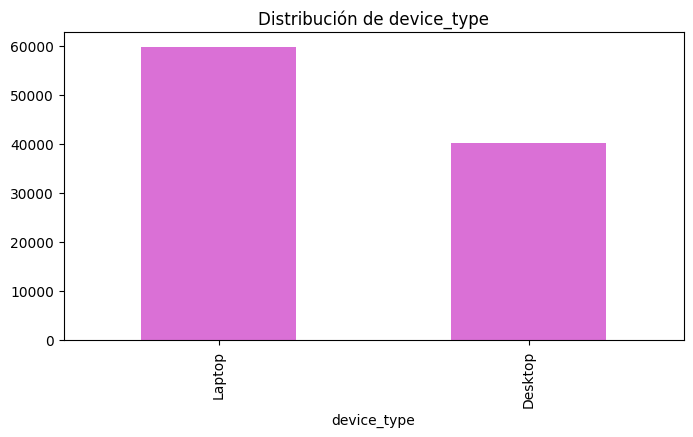

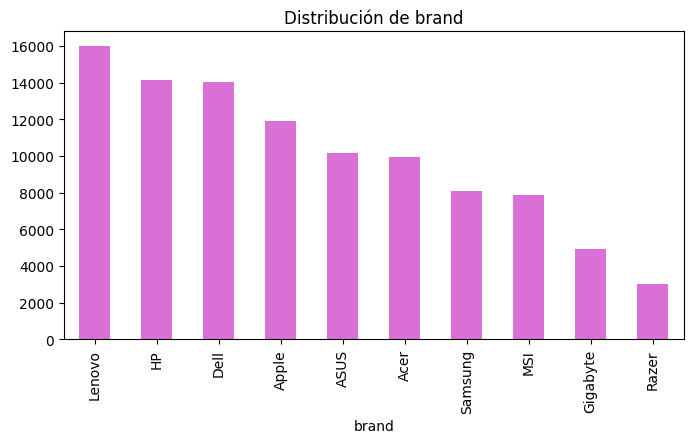

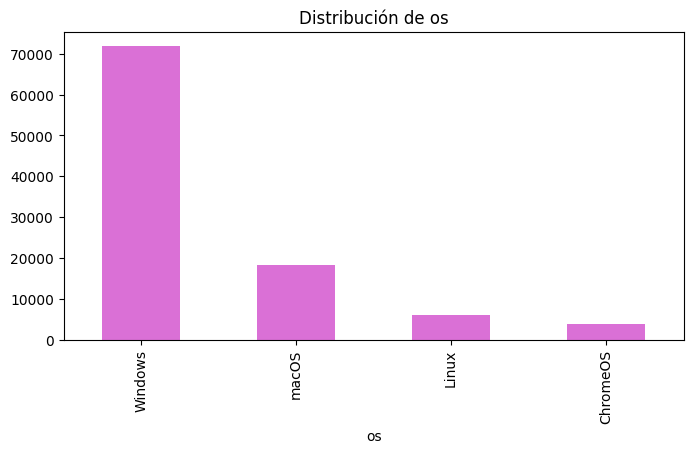

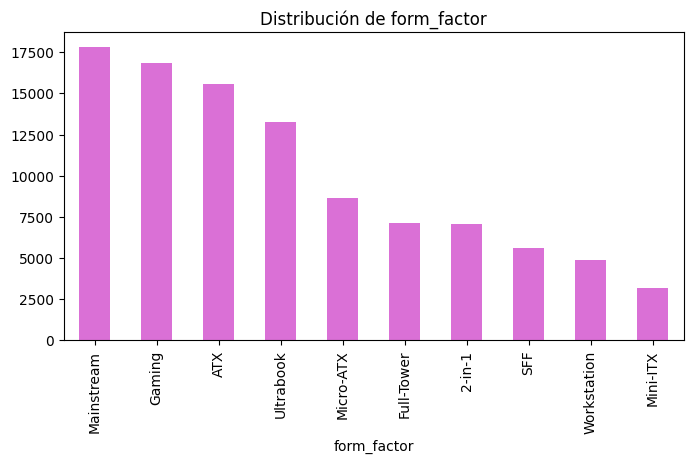

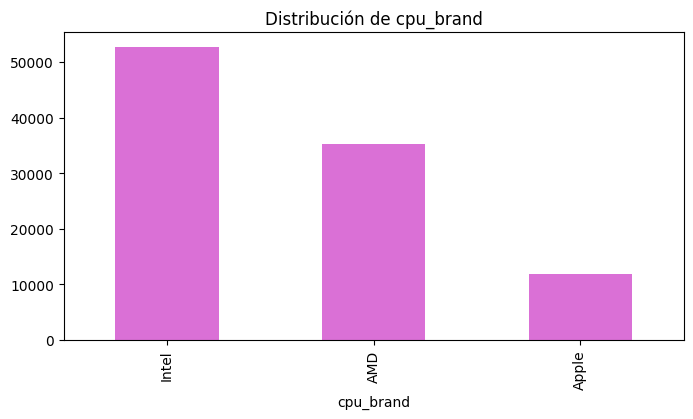

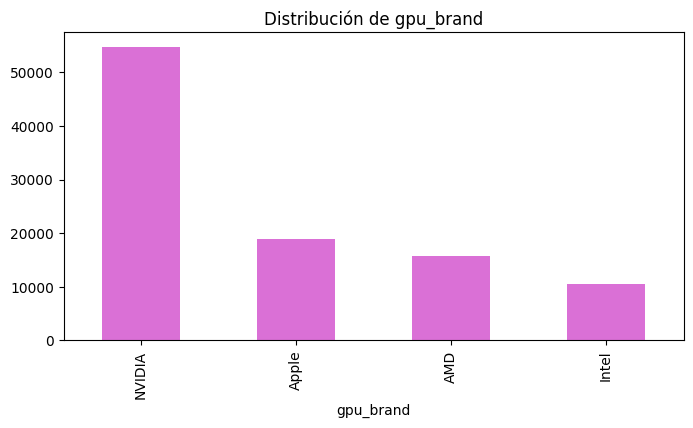

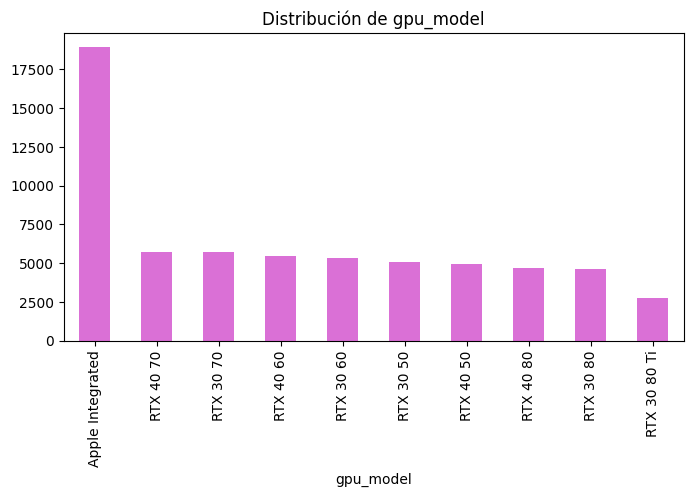

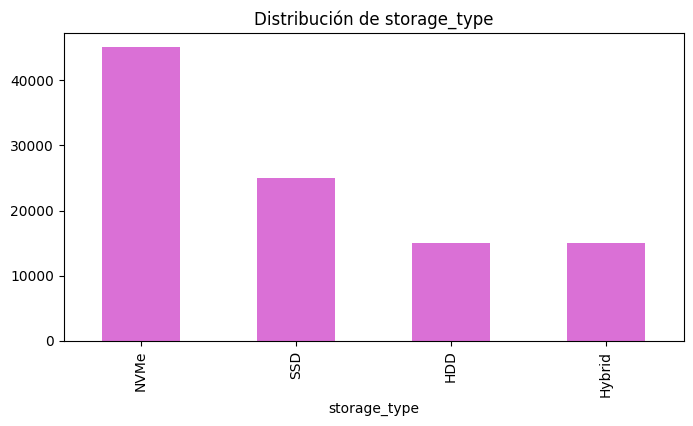

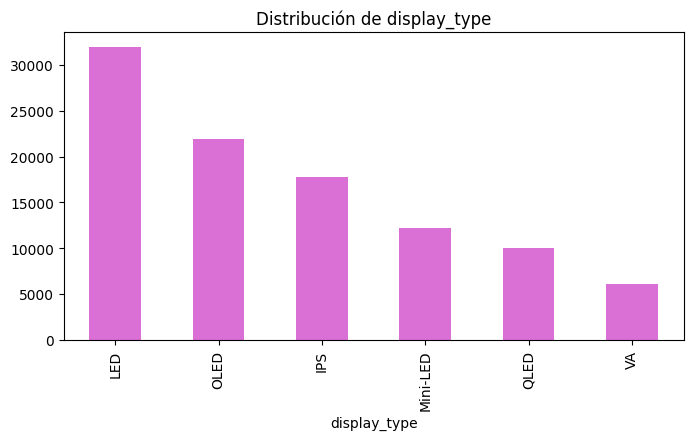

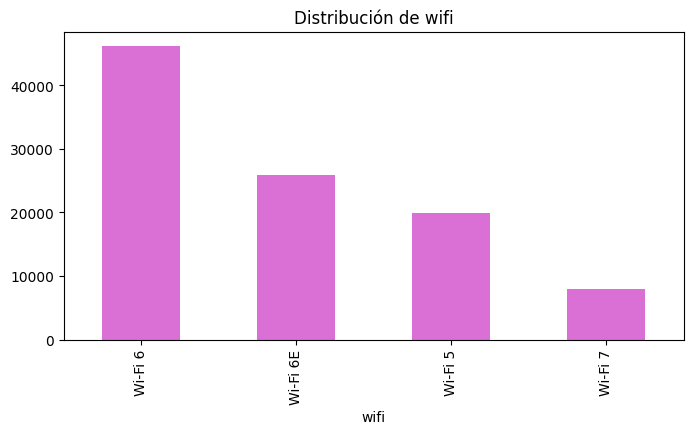

In [12]:
# Histogramas para todas las variables numéricas de golpe
compu_df.hist(bins=30, figsize=(15, 12), color='teal', edgecolor='white')

# Gráficas de barras para las categóricas (Top 10)
for col in compu_df.select_dtypes(include='object').columns:
    plt.figure(figsize=(8, 4))
    compu_df[col].value_counts().head(10).plot(kind='bar', color='orchid')
    plt.title(f"Distribución de {col}")
    plt.show()

3. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Reflexiona sobre cuáles variables representan de manera general la capacidad del hardware y mantenlas; elimina las demás por aportar información redundante.
* Incluye una breve justificación de tus decisiones.

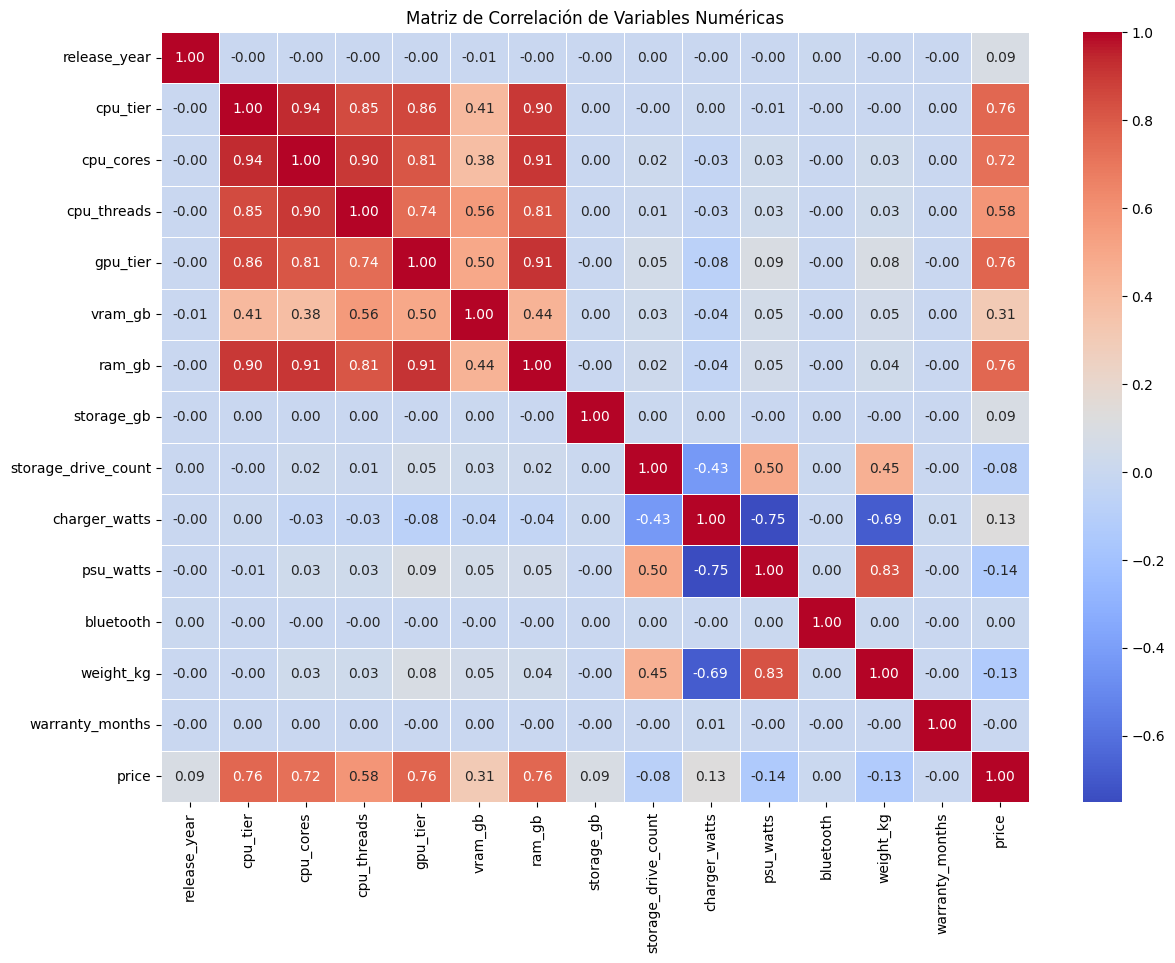

In [13]:
# Filtrar solo las variables numéricas para la correlación
matriz_corr = compu_df.corr(numeric_only=True)

# Dibujamos el mapa de calor
plt.figure(figsize=(14, 10))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

In [14]:
# Filtrar la matriz para ver solo valores mayores a 0.9 (y menores a 1.0 para no ver la diagonal)
pares_altos = matriz_corr[(matriz_corr > 0.9) & (matriz_corr < 1.0)].stack().dropna().drop_duplicates()
pares_altos.to_frame(name='Correlación')

,,Correlación
cpu_tier,cpu_cores,0.937376
cpu_cores,ram_gb,0.906770
gpu_tier,ram_gb,0.912918


In [15]:
# Eliminar las variables redundantes basadas en la alta correlación

compu_df.drop(columns=['cpu_cores', 'ram_gb'], inplace=True)

# Verificamos las columnas que quedaron
compu_df.columns

Index(['device_type', 'brand', 'release_year', 'os', 'form_factor',
       'cpu_brand', 'cpu_tier', 'cpu_threads', 'gpu_brand', 'gpu_model',
       'gpu_tier', 'vram_gb', 'storage_type', 'storage_gb',
       'storage_drive_count', 'display_type', 'charger_watts', 'psu_watts',
       'wifi', 'bluetooth', 'weight_kg', 'warranty_months', 'price'],
      dtype='object')

Se eliminó cpu_cores ya que mostró una correlación de 0.93 con cpu_tier. El "Tier" (gama del 1 al 6) ya es un indicador que agrupa la potencia total del procesador. Dejar los núcleos es como decir "esta es una computadora de gama alta" y luego añadir "y tiene muchos núcleos"; el modelo ya lo sabe por la gama.

Se eliminó ram_gb porque mostró correlaciones de 0.90 y 0.91 con el procesador y la gráfica. En este conjunto de datos, la RAM es "esclava" de la potencia: a mejor CPU/GPU, más RAM. Mantenerla no aporta información nueva que no sepa ya el modelo viendo los componentes principales.

4. Para comenzar con la ingeniería de características, crea una copia del dataframe y asígnala a un nuevo objeto llamado `compu_trans`.
* Calcula cuántos años han pasado desde el lanzamiento de cada computadora y almacénalo en una nueva columna llamada `years_since_release`; luego, elimina la columna original.
* Utiliza `KBinsDiscretizer` para reemplazar la columna `vram_gb` en 4 bins ordinales basados en cuantiles.
* Imprime los valores que delimitan cada bin y haz un histograma para ver la cantidad de observaciones en cada uno, con el fin de entender cómo se agruparon los datos.

In [16]:
# Crear copia del dataframe original
compu_trans = compu_df.copy()

In [17]:
# Transformar año de lanzamiento a antigüedad (Feature Derivation)
# Calcular la edad y eliminamos la fecha original para evitar redundancia
compu_trans['years_since_release'] = 2026 - compu_trans['release_year']
compu_trans.drop(columns=['release_year'], inplace=True)

In [18]:
# Discretización de vram_gb (KBinsDiscretizer)
kbd = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
# Ajustar y transformar
compu_trans['vram_gb'] = kbd.fit_transform(compu_trans[['vram_gb']])

In [19]:
# Resultados de la discretización
# Imprimir los bordes de los intervalos (bins)
display(kbd.bin_edges_)

array([array([ 0.,  4.,  6.,  8., 16.])], dtype=object)

<Axes: >

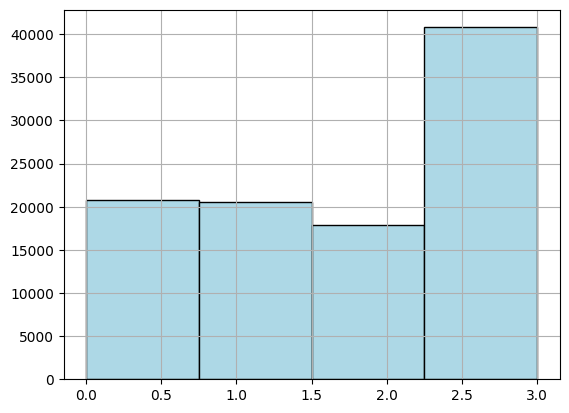

In [20]:
# Histograma para para ver la cantidad de observaciones en cada uno, con el fin de entender cómo se agruparon los datos.
compu_trans['vram_gb'].hist(bins=4, color='lightblue', edgecolor='black')

5. Observa los histogramas del ejercicio 2. Notarás que en las variables `charger_watts` y `psu_watts` aparece una barra en 0. Analiza por qué ocurre esto y qué significa en relación con el tipo de dispositivo.
* Como estas variables son mutuamente excluyentes, combínalas en una nueva columna llamada `power_watts` que contenga la potencia correspondiente de cada dispositivo y, a continuación, haz un histograma para verificar que la distribución resultante es bimodal.
* Por último, borra las columnas originales `charger_watts` y `psu_watts`.

Analisis del ejercicio 2 : Esto no es un error de los datos, sino una característica técnica:

Laptops: Usan un cargador externo (charger_watts). Su valor en psu_watts ,fuente de poder interna de desktop será 0.

Desktops: Usan una fuente de poder interna (psu_watts). Su valor en charger_watts será 0.

Al ser mutuamente excluyentes, podemos unificarlas para tener una sola medida de "potencia de energía".

In [21]:
# Crear la nueva columna combinada
compu_trans['power_watts'] = compu_trans['charger_watts'] + compu_trans['psu_watts']

<Axes: >

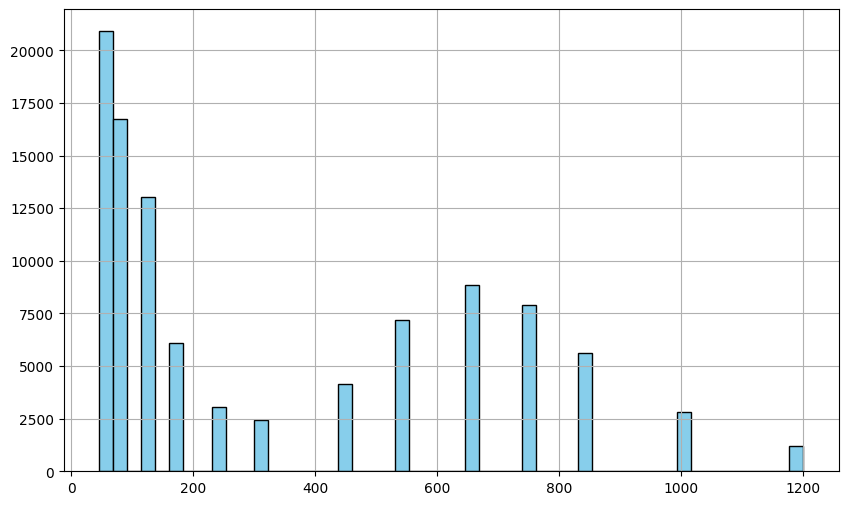

In [22]:
#  Histograma para verificar la bimodalidad
# Usé un número alto de bins (50) para ver los dos picos
compu_trans['power_watts'].hist(bins=50, color='skyblue', edgecolor='black', figsize=(10, 6))

In [23]:
# Eliminar las columnas originales
compu_trans.drop(columns=['charger_watts', 'psu_watts'], inplace=True)

# Mostrar las primeras filas para verificar el cambio
compu_trans[['device_type', 'power_watts']].head()

,device_type,power_watts
0,Desktop,750
1,Laptop,120
2,Desktop,850
3,Desktop,650
4,Laptop,90


6. Para disminuir el sesgo de la variable `price`, crea tres transformadores: logaritmo, raíz cuadrada y Box - Cox.
* Aplica cada transformador a la variable price, dejando el resultado en variables temporales. El objetivo es comparar los efectos de cada transformación antes de decidir cuál aplicar de manera definitiva sobre las variables continuas del dataframe.
* De la variable original y de cada una de las tres transformaciones se debe mostrar:
  * Histograma: para observar la distribución de los datos.
  * Boxplot: para identificar posibles valores atípicos.
  * Q-Q plot: para evaluar la normalidad de la variable.
  * Skew (sesgo): para cuantificar la asimetría de la distribución.
  * Cantidad de outliers: para conocer cuántos valores extremos existen.
* En función de los resultados obtenidos al comparar las transformaciones, decide cuál logró el mejor efecto sobre la distribución de la variable y aplícala directamente en el dataframe, reemplazando las variables continuas: `weight_kg`, `power_watts` y `price`.

,Métrica,Valor
0,Sesgo (Skew),0.986629
1,Outliers,976.000000


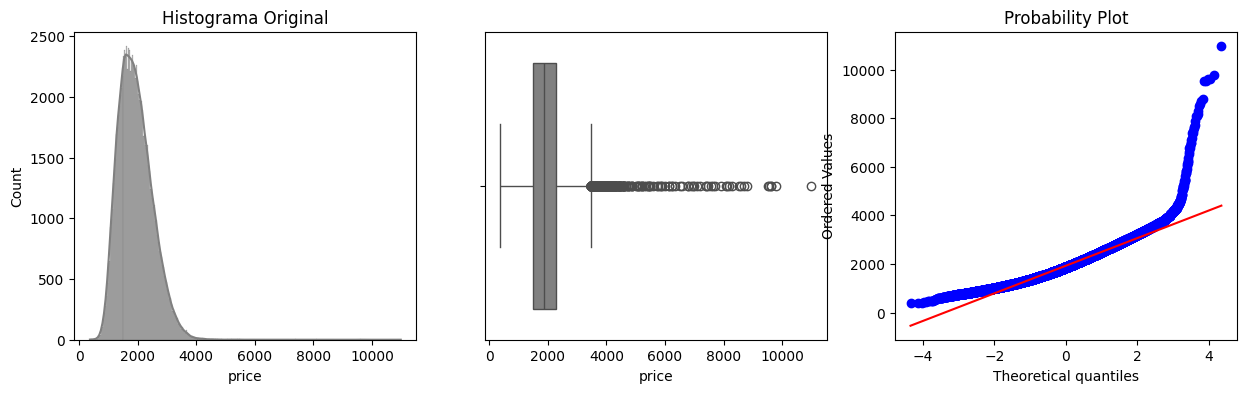

In [24]:
# Análisis: Variable Original
skew_val = stats.skew(compu_trans['price'])
q1, q3 = np.percentile(compu_trans['price'], [25, 75])
iqr = q3 - q1
outliers = ((compu_trans['price'] < (q1 - 1.5 * iqr)) | (compu_trans['price'] > (q3 + 1.5 * iqr))).sum()

# Tabla de resultados
resumen_original = pd.DataFrame({'Métrica': ['Sesgo (Skew)', 'Outliers'], 'Valor': [skew_val, outliers]})
display(resumen_original)

# Gráficas
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(compu_trans['price'], kde=True, ax=ax[0], color='gray')
sns.boxplot(x=compu_trans['price'], ax=ax[1], color='gray')
stats.probplot(compu_trans['price'], dist="norm", plot=ax[2])
ax[0].set_title('Histograma Original')
plt.show()

,Transformación,Sesgo,Outliers
0,Logaritmo,-0.132599,387


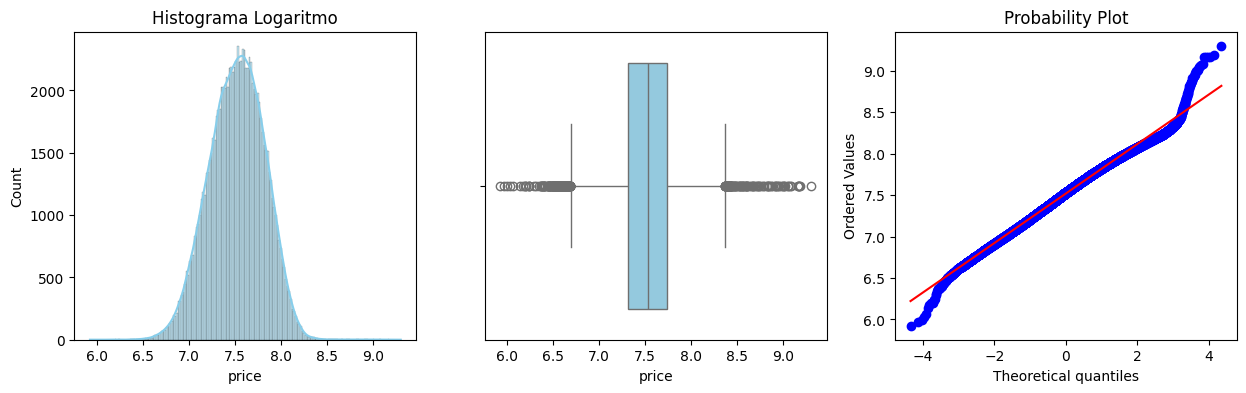

In [25]:
#Transformacion logaritmo
price_log = np.log1p(compu_trans['price'])

# Métricas
skew_log = stats.skew(price_log)
q1, q3 = np.percentile(price_log, [25, 75])
iqr = q3 - q1
out_log = ((price_log < (q1 - 1.5 * iqr)) | (price_log > (q3 + 1.5 * iqr))).sum()

display(pd.DataFrame({'Transformación': ['Logaritmo'], 'Sesgo': [skew_log], 'Outliers': [out_log]}))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(price_log, kde=True, ax=ax[0], color='skyblue')
sns.boxplot(x=price_log, ax=ax[1], color='skyblue')
stats.probplot(price_log, dist="norm", plot=ax[2])
ax[0].set_title('Histograma Logaritmo')
plt.show()

,Transformación,Sesgo,Outliers
0,Raíz Cuadrada,0.332248,364


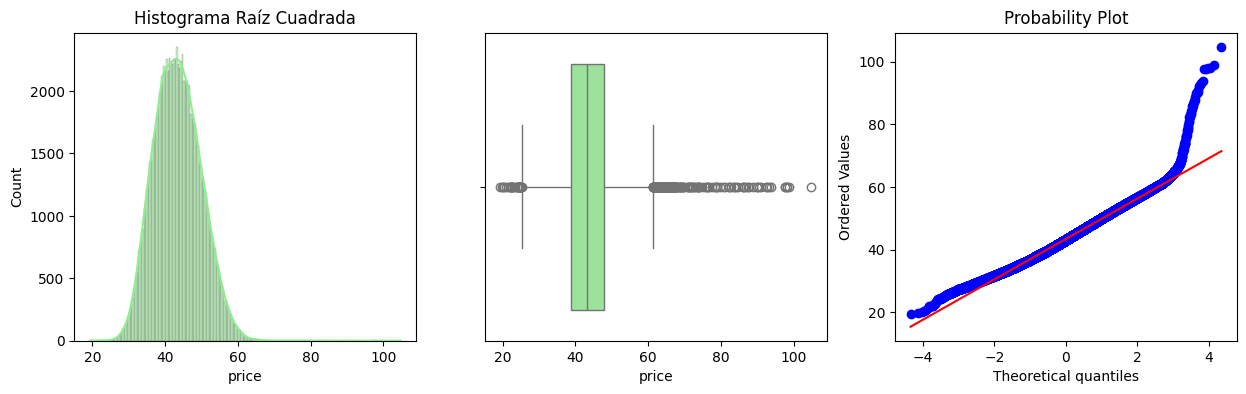

In [26]:
#Transformacion Raiz cuadrada
price_sqrt = np.sqrt(compu_trans['price'])

# Métricas
skew_sqrt = stats.skew(price_sqrt)
q1, q3 = np.percentile(price_sqrt, [25, 75])
iqr = q3 - q1
out_sqrt = ((price_sqrt < (q1 - 1.5 * iqr)) | (price_sqrt > (q3 + 1.5 * iqr))).sum()

display(pd.DataFrame({'Transformación': ['Raíz Cuadrada'], 'Sesgo': [skew_sqrt], 'Outliers': [out_sqrt]}))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(price_sqrt, kde=True, ax=ax[0], color='lightgreen')
sns.boxplot(x=price_sqrt, ax=ax[1], color='lightgreen')
stats.probplot(price_sqrt, dist="norm", plot=ax[2])
ax[0].set_title('Histograma Raíz Cuadrada')
plt.show()

,Transformación,Sesgo,Outliers
0,Box-Cox,-0.000238,317


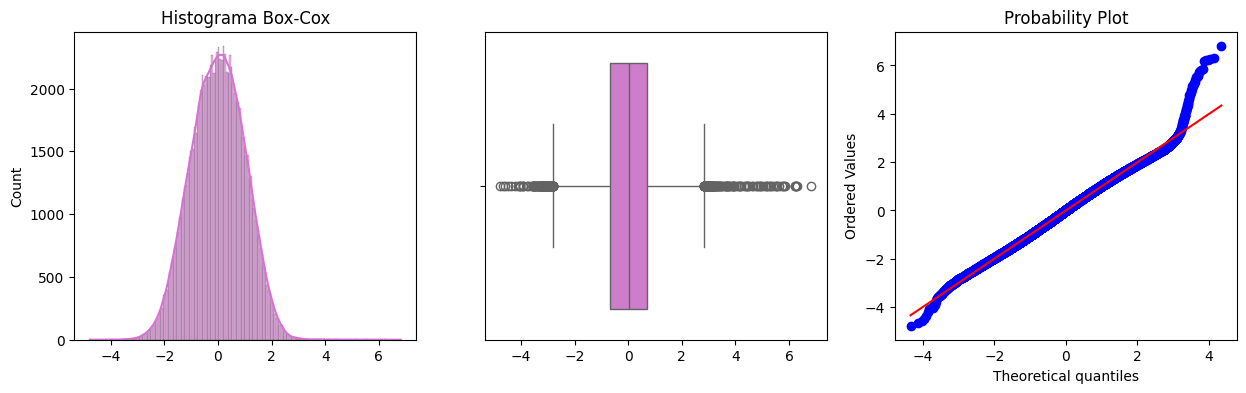

In [27]:
#Transformacion box-cox
pt = PowerTransformer(method='box-cox')
price_boxcox = pt.fit_transform(compu_trans[['price']]).flatten()

# Métricas
skew_bc = stats.skew(price_boxcox)
q1, q3 = np.percentile(price_boxcox, [25, 75])
iqr = q3 - q1
out_bc = ((price_boxcox < (q1 - 1.5 * iqr)) | (price_boxcox > (q3 + 1.5 * iqr))).sum()

display(pd.DataFrame({'Transformación': ['Box-Cox'], 'Sesgo': [skew_bc], 'Outliers': [out_bc]}))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(price_boxcox, kde=True, ax=ax[0], color='orchid')
sns.boxplot(x=price_boxcox, ax=ax[1], color='orchid')
stats.probplot(price_boxcox, dist="norm", plot=ax[2])
ax[0].set_title('Histograma Box-Cox')
plt.show()

 Box-Cox es la que mejor logró el mejor efecto sobre la distribución de la variable  por tres razones

Outliers: Box-Cox redujo la cantidad a 317, mientras que el Logaritmo tiene 387 y la Raíz Cuadrada 364. Esto significa que Box-Cox logró acercar más los valores extremos al centro.

Sesgo: El sesgo de Box-Cox es casi cero (-0.0002), lo que indica una simetría casi perfecta. El Logaritmo se pasó un poco al lado negativo (-0.13) y la Raíz se quedó corta en el positivo (0.33).

Q-Q Plot: En la línea roja de la tercera imagen, los puntos azules de Box-Cox están mucho más pegaditos a la diagonal en la parte central que en las otras dos, lo que confirma que lograste la mejor normalización.

In [28]:
# CreaR el objeto PowerTransformer especificando 'box-cox'
#  Box-Cox
pt = PowerTransformer(method='box-cox')

# Definir las columnas que la actividad pide transformar
columnas_continuas = ['weight_kg', 'power_watts', 'price']

#  Ajustar y transformar al mismo tiempo

compu_trans[columnas_continuas] = pt.fit_transform(compu_trans[columnas_continuas])

# Mostramos el sesgo para confirmar que ahora están cerca de 0
compu_trans[columnas_continuas].skew().to_frame(name='Sesgo Final (Box-Cox)')

,Sesgo Final (Box-Cox)
weight_kg,0.213748
power_watts,0.086581
price,-0.000238


7. Para que todas las variables numéricas estén en la misma escala, aplica `MinMaxScaler` de sklearn a todas las columnas numéricas del dataframe, reemplazando las columnas originales.

In [29]:
# Crear el objeto escalador
scaler = MinMaxScaler()

# Identificar todas las columnas numéricas automáticamente

columnas_numericas = compu_trans.select_dtypes(include=['number']).columns

# Aplicar el escalado y reemplazar en el dataframe
compu_trans[columnas_numericas] = scaler.fit_transform(compu_trans[columnas_numericas])


In [31]:
# Verificar: mostrar los valores mínimos y máximos
display(compu_trans[columnas_numericas].agg(['min', 'max']))



,cpu_tier,cpu_threads,gpu_tier,vram_gb,storage_gb,storage_drive_count,bluetooth,weight_kg,warranty_months,price,years_since_release,power_watts
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [32]:
# Visualizar el resultado final de la tabla
compu_trans.head()

,device_type,brand,os,form_factor,cpu_brand,cpu_tier,cpu_threads,gpu_brand,gpu_model,gpu_tier,...,storage_gb,storage_drive_count,display_type,wifi,bluetooth,weight_kg,warranty_months,price,years_since_release,power_watts
0,Desktop,Samsung,Windows,ATX,Intel,0.4,0.384615,NVIDIA,RTX 40 60,0.2,...,0.200000,0.000000,LED,Wi-Fi 6,0.818182,0.932995,0.666667,0.328669,0.428571,0.887860
1,Laptop,Samsung,Windows,Mainstream,Intel,0.6,0.384615,NVIDIA,RTX 40 80,0.6,...,0.066667,0.000000,OLED,Wi-Fi 6,1.000000,0.423737,0.000000,0.471202,0.428571,0.357238
2,Desktop,Lenovo,macOS,SFF,AMD,0.2,0.230769,NVIDIA,RTX 40 50,0.0,...,0.066667,0.333333,LED,Wi-Fi 6,0.727273,0.834353,0.333333,0.415246,0.142857,0.918578
3,Desktop,Dell,Windows,ATX,AMD,0.2,0.153846,AMD,RX 7000 60,0.2,...,0.066667,0.333333,IPS,Wi-Fi 6,0.909091,0.795505,0.666667,0.318122,0.142857,0.851953
4,Laptop,Gigabyte,Linux,Gaming,AMD,0.8,0.538462,NVIDIA,RTX 30 80 Ti,0.8,...,0.000000,0.000000,Mini-LED,Wi-Fi 6,0.909091,0.280423,0.000000,0.520800,0.142857,0.258382


8. Aunque `wifi` es una variable categórica, sus categorías tienen un orden natural (Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7). Codifícala usando `OrdinalEncoder`.
* Luego, escala la variable codificada entre 0 y 1 con `MinMaxScaler`, para que quede en la misma escala que las variables numéricas del dataframe.

Nota: Ambos cambios deben efectuarse sobre la columna original, de manera que quede una única columna `wifi` con toda la información transformada.

In [33]:
# Definición del orden jerárquico de las tecnologías
orden_wifi = [['Wi-Fi 4', 'Wi-Fi 5', 'Wi-Fi 6', 'Wi-Fi 6E', 'Wi-Fi 7']]

# Inicialización de transformadores
encoder = OrdinalEncoder(categories=orden_wifi)
scaler = MinMaxScaler()

# Aplicación de codificación ordinal sobre la columna original
compu_trans['wifi'] = encoder.fit_transform(compu_trans[['wifi']])

# Aplicación de escalado Min-Max para normalizar el rango a [0, 1]
compu_trans['wifi'] = scaler.fit_transform(compu_trans[['wifi']])

In [35]:
# Visualización del resultado final
compu_trans['wifi'].value_counts()

,count
wifi,
0.333333,46149
0.666667,25923
0.000000,19926
1.000000,8002


9. La variable `gpu_model` tiene muchas categorías. Usar *One-Hot Encoding* aumentaría significativamente la dimensionalidad del dataframe. Por ello, utiliza `BinaryEncoder` para codificarla.
* Guarda el resultado en un dataframe llamado `bin_df`. Más adelante, lo combinarás con `compu_transf` para integrar las variables codificadas.

In [38]:
# Inicializamos el codificador directamente
encoder_binary = BinaryEncoder(cols=['gpu_model'])

# Creamos el dataframe bin_df con la transformación de la columna gpu_model
bin_df = encoder_binary.fit_transform(compu_trans['gpu_model'])

# Visualizamos las primeras filas para verificar las nuevas columnas
bin_df.head()

,gpu_model_0,gpu_model_1,gpu_model_2,gpu_model_3,gpu_model_4,gpu_model_5
0,0,0,0,0,0,1
1,0,0,0,0,1,0
2,0,0,0,0,1,1
3,0,0,0,1,0,0
4,0,0,0,1,0,1


10. Usa `OneHotEncoder` para codificar las variables categóricas restantes. Asegúrate de usar `drop='first'` para evitar la multicolinealidad y guarda el resultado en un dataframe llamado `ohe_df`
* Combina el dataframe `compu_transf` con las variables categóricas que fueron codificadas en `bin_df` y `ohe_df`. No olvides eliminar las variables originales.
* Usa `describe()` sobre el dataframe resultante para corroborar que todas las columnas estén escaladas entre 0 y 1 y que no queden variables categóricas sin codificar.

In [39]:
# Identificar las variables categóricas que faltan excepto gpu_model que ya está en bin_df
# BRAND, DEVICE_TYPE, OS, FORM_FACTOR, CPU_BRAND, CPU_TIER, GPU_BRAND, GPU_TIER, DISPLAY_TYPE, BLUETOOTH
columnas_ohe = compu_trans.select_dtypes(include=['object']).columns.drop(['gpu_model'])

# Configurar el OneHotEncoder con drop='first' para evitar la multicolinealidad
ohe = OneHotEncoder(sparse_output=False, drop='first')

# Creamos ohe_df con las nuevas columnas
ohe_data = ohe.fit_transform(compu_trans[columnas_ohe])
ohe_df = pd.DataFrame(ohe_data, columns=ohe.get_feature_names_out(columnas_ohe), index=compu_trans.index)

In [40]:
# Combinar todo: compu_trans + bin_df + ohe_df
# Primero eliminar TODAS las originales de texto para que no se dupliquen
compu_final = compu_trans.drop(columns=compu_trans.select_dtypes(include=['object']).columns)
compu_final = pd.concat([compu_final, bin_df, ohe_df], axis=1)


In [41]:
# 5. Verificación final
compu_final.describe()

,cpu_tier,cpu_threads,gpu_tier,vram_gb,storage_gb,storage_drive_count,wifi,bluetooth,weight_kg,warranty_months,...,gpu_brand_Intel,gpu_brand_NVIDIA,storage_type_Hybrid,storage_type_NVMe,storage_type_SSD,display_type_LED,display_type_Mini-LED,display_type_OLED,display_type_QLED,display_type_VA
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.430698,0.295629,0.398270,0.595883,0.168733,0.174993,0.406670,0.804331,0.517032,0.283343,...,0.105990,0.547120,0.149810,0.450590,0.249370,0.320000,0.121880,0.219100,0.100690,0.060910
std,0.274635,0.186893,0.291929,0.394170,0.201626,0.265761,0.284834,0.223616,0.293982,0.284219,...,0.307826,0.497777,0.356887,0.497555,0.432651,0.466478,0.327149,0.413639,0.300919,0.239166
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,0.153846,0.200000,0.333333,0.066667,0.000000,0.333333,0.727273,0.280423,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.400000,0.230769,0.400000,0.666667,0.066667,0.000000,0.333333,0.818182,0.417162,0.333333,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.600000,0.384615,0.600000,1.000000,0.200000,0.333333,0.666667,0.909091,0.834353,0.333333,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
